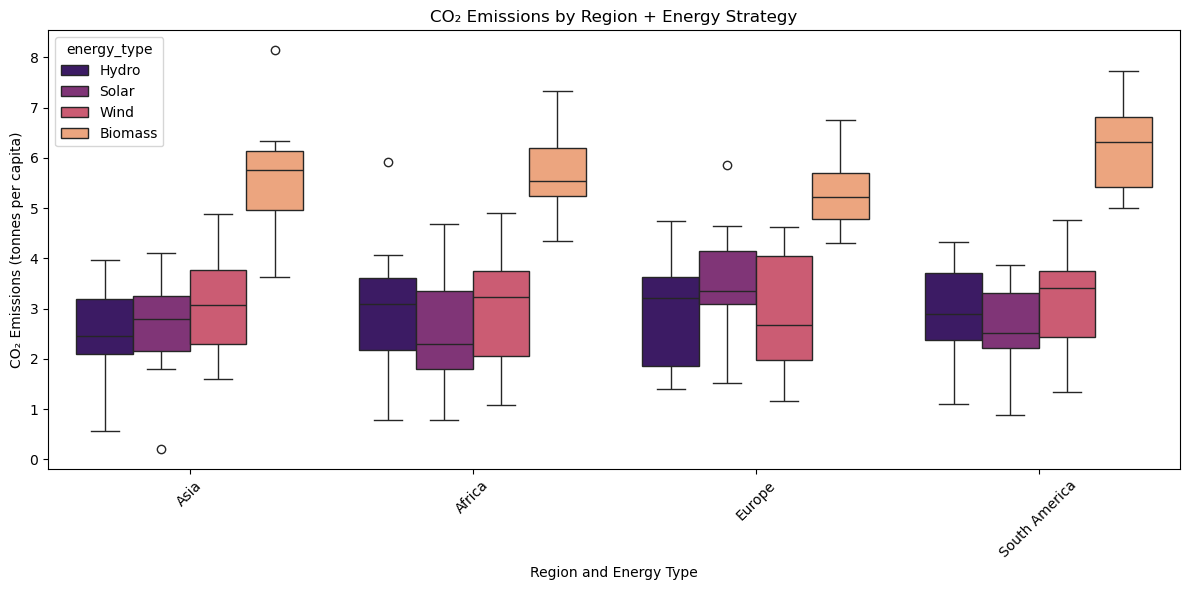

In [10]:

# Week 4 – Box Plot Visualization for Categorical Features

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Step 1: Simulated dataset
regions = ['Asia', 'Africa', 'Europe', 'South America']
energy_types = ['Solar', 'Wind', 'Hydro', 'Biomass']

# Generate combinations
data = []
for region in regions:
    for energy in energy_types:
        for _ in range(10):  # 10 data points per category
            co2 = random.gauss(mu=6 if energy == 'Biomass' else 3, sigma=1.2)
            data.append([region, energy, round(max(co2, 0.2), 2)])  # Ensure no negative emissions

df = pd.DataFrame(data, columns=['region', 'energy_type', 'co2_emissions'])



# Step 2: Create new combined category
df['region_energy'] = df['region'] + "_" + df['energy_type']
order = df.groupby('region_energy')['co2_emissions'].median().sort_values().index

energy_order = df.groupby('energy_type')['co2_emissions'].median().sort_values().index

# Step 3: Plot box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='region', y='co2_emissions', hue='energy_type', hue_order=energy_order, 
            palette='magma')
plt.title("CO₂ Emissions by Region + Energy Strategy")
plt.xticks(rotation=45)
plt.ylabel("CO₂ Emissions (tonnes per capita)")
plt.xlabel("Region and Energy Type")
plt.tight_layout()
plt.show()
